# Loan Approval Prediction — Decision Tree

Predicting whether a bank loan application will be approved, using a Decision Tree
classifier with pruning. Dataset: Kaggle Loan Prediction dataset (614 applicants, 13 features).

**Goal:** identify which applicant factors most influence loan approval, and build a
model that generalizes well (avoids overfitting) rather than one that simply memorizes
the training data.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv"
df = pd.read_csv(url)

Loads the **Loan Prediction dataset** (614 rows) directly from a GitHub raw CSV mirror into a pandas DataFrame, without needing to download the file manually

In [2]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Shows the first 5 rows. Confirms the dataset structure: a mix of **categorical columns** (Gender, Married, Education, Property_Area) and **numerical columns** (ApplicantIncome, LoanAmount), with the target Loan_Status at the end. Row 0 already shows a missing LoanAmount value (NaN) — an early sign that cleaning will be needed.

In [3]:
df.shape

(614, 13)

Output: (614, 13).
Confirms 614 applicants and 13 columns, matching the expected dataset size — a small.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Reveals column data types and non-null counts. **Seven columns** have **missing values** (Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, Credit_History), while ApplicantIncome, Education, Property_Area, and Loan_Status are complete. Also notable: Credit_History is stored as float64 even though it's conceptually binary (0/1).

In [5]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


Quantifies the missing values seen in .info().

**Credit_History** has the most gaps (50), followed by Self_Employed (32) and LoanAmount (22). This count directly informs the imputation strategy in later cells.

In [6]:
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


***Output:*** Y=422, N=192 (≈69%/31%).

Reveals class imbalance — approved loans are more than twice as common as rejections. This is an important caveat to mention later when interpreting accuracy, since a model could score deceptively well by just guessing "Approved" often.

In [7]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

*Fills missing values* in Gender, Married, Dependents, and Self_Employed with each column's most frequent value. Mode is the appropriate choice here because these are categories, not numbers — there's no meaningful "average" gender or marital status.

In [8]:
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median())

Uses median rather than mean because LoanAmount likely contains outliers (a few very large loans), which would skew the mean upward. Median is more robust to this kind of skew.

In [9]:
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

**Credit_History** is conceptually a 0/1 category, not a continuous number — so mode (not median) is the correct fill strategy.

In [10]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


All columns now **show 0 missing values**. Confirms the cleaning steps worked correctly before moving on.

In [11]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})
df["Married"] = df["Married"].map({"Yes": 1, "No": 0})
df["Education"] = df["Education"].map({"Graduate": 1, "Not Graduate": 0})
df["Self_Employed"] = df["Self_Employed"].map({"Yes": 1, "No": 0})
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})

Converts **five binary text columns** (Gender, Married, Education, Self_Employed, and the target Loan_Status) into 0/1 integers. This is required because **Decision Tree models** (like nearly all ML algorithms) can't process raw text.

In [12]:
df["Property_Area"] = df["Property_Area"].map({"Rural": 0, "Semiurban": 1, "Urban": 2})

Manually maps the **three-category column** to integers, giving explicit control over the **encoding** rather than relying on an **automatic encoder**.

In [13]:
df["Dependents"] = df["Dependents"].replace("3+", 4)
df["Dependents"] = df["Dependents"].astype(int)

Handles the special case of "3+" (**a string, not a number**) by replacing it with 4, then converts the whole column to **integer type**.

In [14]:
df.head()
df.dtypes

,0
Loan_ID,object
Gender,int64
Married,int64
Dependents,int64
Education,int64
Self_Employed,int64
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


Confirms every column except Loan_ID is **numeric** (int64/float64). Loan_ID is left as-is here since it will simply be dropped before training, not used as a feature.

In [15]:
X = df.drop(columns=["Loan_ID", "Loan_Status"])
y = df["Loan_Status"]

Removes Loan_ID (a meaningless identifier with no predictive value) and *separates the target column* into y.

In [16]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Splits data 80/20. stratify=y is especially important here given the 69/31 class imbalance found in Cell 5 — it ensures both the train and test sets preserve that same ratio.

In [18]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_tr, y_tr)

print("Train accuracy:", model.score(X_tr, y_tr))
print("Test accuracy:", model.score(X_te, y_te))
print("Depth:", model.get_depth())
print("Number of leaves:", model.get_n_leaves())

Train accuracy: 1.0
Test accuracy: 0.7560975609756098
Depth: 19
Number of leaves: 115


**Output:** *Train* *accuracy*: 1.0,

*Test* *accuracy*: 0.756,

*Depth*: 19,

*Leaves:* 115.

**Classic overfitting:** the tree grew until every leaf was pure, memorizing the training data (115 leaves for only 491 training rows) instead of learning generalizable rules. This establishes the baseline problem that pruning will solve.

In [19]:
depths = range(1, 16)
train_scores = []
test_scores = []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_tr, y_tr)
    train_scores.append(m.score(X_tr, y_tr))
    test_scores.append(m.score(X_te, y_te))

for d, tr, te in zip(depths, train_scores, test_scores):
    print(f"depth={d}: train={tr:.3f}, test={te:.3f}")

depth=1: train=0.798, test=0.854
depth=2: train=0.804, test=0.854
depth=3: train=0.809, test=0.846
depth=4: train=0.809, test=0.846
depth=5: train=0.825, test=0.821
depth=6: train=0.843, test=0.829
depth=7: train=0.864, test=0.805
depth=8: train=0.882, test=0.797
depth=9: train=0.902, test=0.780
depth=10: train=0.916, test=0.789
depth=11: train=0.937, test=0.805
depth=12: train=0.951, test=0.780
depth=13: train=0.967, test=0.789
depth=14: train=0.969, test=0.764
depth=15: train=0.978, test=0.764


Shows train accuracy rising steadily while test accuracy peaks early (0.854 at depth 1–2) and then declines as depth increases. Here the shallowest trees generalize best — a strong hint that one dominant feature is doing most of the work.

In [20]:
leaf_sizes = [1, 5, 10, 15, 20, 30]

for ms in leaf_sizes:
    m = DecisionTreeClassifier(min_samples_leaf=ms, random_state=42)
    m.fit(X_tr, y_tr)
    print(f"min_samples_leaf={ms}: train={m.score(X_tr, y_tr):.3f}, test={m.score(X_te, y_te):.3f}")

min_samples_leaf=1: train=1.000, test=0.756
min_samples_leaf=5: train=0.855, test=0.715
min_samples_leaf=10: train=0.827, test=0.821
min_samples_leaf=15: train=0.807, test=0.797
min_samples_leaf=20: train=0.807, test=0.821
min_samples_leaf=30: train=0.798, test=0.854


Confirms the same pattern from another angle: the most constrained setting (min_samples_leaf=30) achieves the best test score (0.854), while the least constrained (min_samples_leaf=1, no constraint) overfits (train=1.000, test=0.756).

In [22]:
best_model = DecisionTreeClassifier(max_depth=2, random_state=42)
best_model.fit(X_tr, y_tr)

from sklearn.tree import export_text
print(export_text(best_model, feature_names=list(X.columns)))

|--- Credit_History <= 0.50
|   |--- CoapplicantIncome <= 8115.00
|   |   |--- class: 0
|   |--- CoapplicantIncome >  8115.00
|   |   |--- class: 1
|--- Credit_History >  0.50
|   |--- CoapplicantIncome <= 9537.00
|   |   |--- class: 1
|   |--- CoapplicantIncome >  9537.00
|   |   |--- class: 0



The printed tree shows Credit_History at the root. However, the second-level splits on CoapplicantIncome produce contradictory logic (high income helps in one branch but hurts in the other) — a sign of the model fitting noise rather than a real pattern.

In [23]:
import pandas as pd

importances = pd.Series(best_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

Credit_History       0.933185
CoapplicantIncome    0.066815
Gender               0.000000
Dependents           0.000000
Married              0.000000
Self_Employed        0.000000
Education            0.000000
ApplicantIncome      0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Property_Area        0.000000
dtype: float64


**Output:** Credit_History = 0.933, CoapplicantIncome = 0.067, all other 10 features = 0.000. Quantitatively confirms the earlier observation: Credit_History alone accounts for 93.3% of the model's decision-making, explaining why shallow trees outperform deep ones.

In [24]:
from sklearn.model_selection import GridSearchCV

grid = {
    "max_depth": [1, 2, 3, 4, 5, None],
    "min_samples_leaf": [1, 5, 10, 20, 30],
    "criterion": ["gini", "entropy"],
}

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), grid, cv=5, n_jobs=-1)
gs.fit(X_tr, y_tr)

print("Best params:", gs.best_params_)
print("CV score:", gs.best_score_)
print("Test score:", gs.best_estimator_.score(X_te, y_te))

Best params: {'criterion': 'gini', 'max_depth': 1, 'min_samples_leaf': 1}
CV score: 0.7983714698000413
Test score: 0.8536585365853658


Output: *Best params*: {criterion: gini, max_depth: 1, min_samples_leaf: 1},

*CV score*: 0.798,

*Test score*: 0.854.

A systematic, cross-validated search confirms what the manual sweeps suggested: a single-split tree (depth=1) generalizes best, avoiding the need to guess parameters by eye.

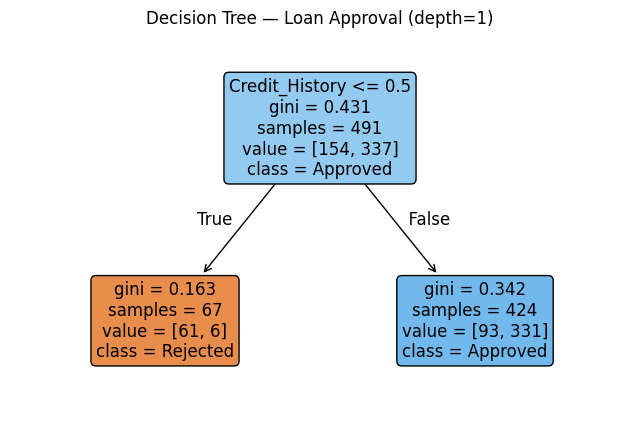

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

final_model = gs.best_estimator_

plt.figure(figsize=(8, 5))
plot_tree(final_model, feature_names=list(X.columns),
          class_names=["Rejected", "Approved"],
          filled=True, rounded=True, fontsize=12)
plt.title("Decision Tree — Loan Approval (depth=1)")
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()

Plots the **depth=1** tree with plot_tree(), colored by class, and saves it as decision_tree.png. It shows the entire model logic in one image: applicants with poor credit history are rejected ~91% of the time; those with good credit history are approved ~78% of the time.

## Conclusion

- The unconstrained tree overfit severely (train=100%, test=75.6%).
- Credit_History alone accounts for 93.3% of feature importance — by far the
  dominant predictor of loan approval.
- The best-generalizing model (found via GridSearchCV) is a single-split tree
  (depth=1), achieving 85.4% test accuracy — outperforming every deeper tree tried.
- Applicants with poor credit history are rejected ~91% of the time; those with
  good credit history are approved ~78% of the time.

**Takeaway:** more complexity ≠ better performance. A simple, interpretable model
based on the single strongest signal generalized better than deeper trees that
picked up noise (e.g. the contradictory CoapplicantIncome splits at depth=2).
